# Project 4 — Supervised Classification on German Credit Risk (MLPs with Keras)

This project rebuilds the Project 2 classifier using a Keras MLP. The preprocessing step is adapted to produce dense, numeric arrays suitable for a Keras input layer.

## Data Preparation

### Loading the Dataset

In [2]:
import openml
import pandas as pd

# 1. Fetch the dataset using its ID
dataset = openml.datasets.get_dataset(31)

# 2. Get the data, specifying 'class' as the target variable
X, y, categorical_indicator, attribute_names = dataset.get_data(target="class")

df = pd.concat([X, y], axis=1)

### Train / Validation / Test Split

As in Project 2, we hold out a 20% test set. Since Keras training also needs a validation set to monitor learning curves, we further split the remaining 80% into training and validation sets, giving roughly a 64% / 16% / 20% train/validation/test split overall.

In [3]:
from sklearn.model_selection import train_test_split

# First split off the test set (same as Project 2)
X_train_full, X_test, y_train_full, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Further split the remaining data into training and validation sets
X_train, X_valid, y_train, y_valid = train_test_split(
    X_train_full, y_train_full, test_size=0.2, random_state=42, stratify=y_train_full
)

print(f"Training set size:   {X_train.shape[0]}")
print(f"Validation set size: {X_valid.shape[0]}")
print(f"Testing set size:    {X_test.shape[0]}")

Training set size:   640
Validation set size: 160
Testing set size:    200


### Initial Inspection

In [4]:
# Display the first few rows
print(X.head())

# Check for data types and missing values
print(X.info())

# Statistical summary of numerical features
print(X.describe())

  checking_status  duration                  credit_history  \
0              <0         6  critical/other existing credit   
1        0<=X<200        48                   existing paid   
2     no checking        12  critical/other existing credit   
3              <0        42                   existing paid   
4              <0        24              delayed previously   

               purpose  credit_amount    savings_status employment  \
0             radio/tv         1169.0  no known savings        >=7   
1             radio/tv         5951.0              <100     1<=X<4   
2            education         2096.0              <100     4<=X<7   
3  furniture/equipment         7882.0              <100     4<=X<7   
4              new car         4870.0              <100     1<=X<4   

   installment_commitment     personal_status other_parties  residence_since  \
0                       4         male single          none                4   
1                       2  female div/de

This output shows an overview of the German Credit dataset. It contains 1,000 entries across 20 different attributes, with a mix of categorical and numerical data types.

#### Checking for missing values.

In [5]:
# Check for null values
print(X.isnull().sum())

checking_status           0
duration                  0
credit_history            0
purpose                   0
credit_amount             0
savings_status            0
employment                0
installment_commitment    0
personal_status           0
other_parties             0
residence_since           0
property_magnitude        0
age                       0
other_payment_plans       0
housing                   0
existing_credits          0
job                       0
num_dependents            0
own_telephone             0
foreign_worker            0
dtype: int64


This shows there are no missing values in the dataset.

#### Understanding the target variable.

In [6]:
# Check class distribution
print(y.value_counts(normalize=True))

class
good    0.7
bad     0.3
Name: proportion, dtype: float64


This shows us that the dataset is imbalanced, with 70% having good credit and 30% having bad credit.

### Visualizing the Dataset

To help understand the data, we use histograms and boxplots to get a better representation of the content in the dataset. This allows us to check for outliers and get more insight into the distributions.

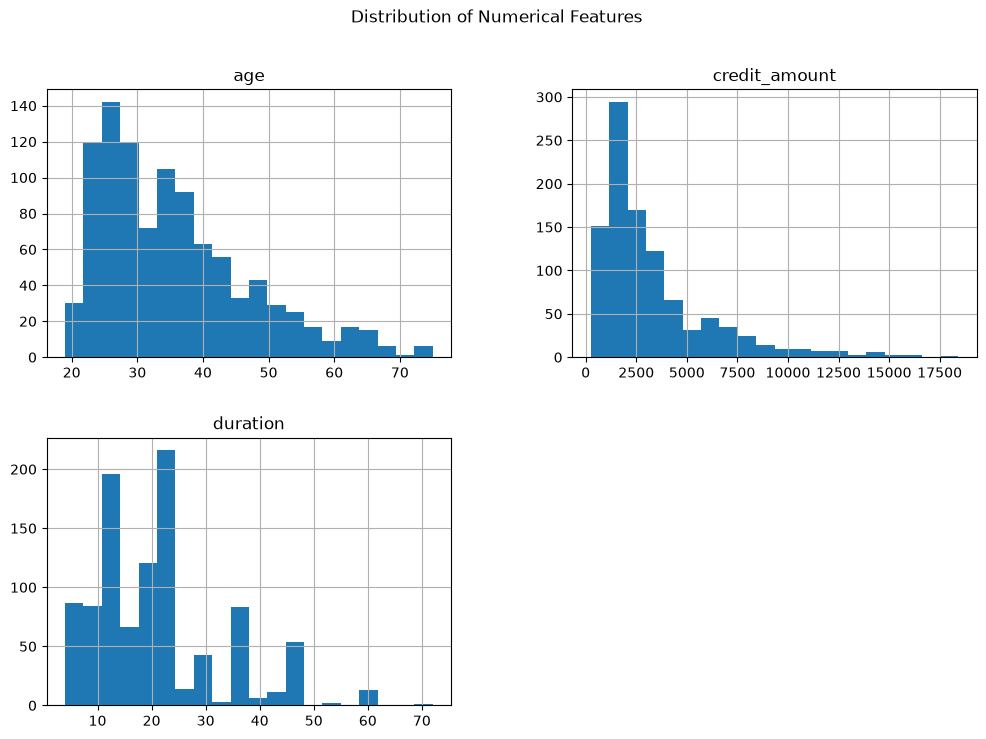

In [7]:
import matplotlib.pyplot as plt

# Select numerical columns
num_cols = ['age', 'credit_amount', 'duration']

# Plot histograms
df[num_cols].hist(bins=20, figsize=(12, 8))
plt.suptitle('Distribution of Numerical Features')
plt.show()

The histograms illustrate that the **age** and **credit_amount** features exhibit a right-skewed distribution, showing that the majority of applicants are younger and request smaller loan amounts. Next, we examine the boxplot to check for outliers:

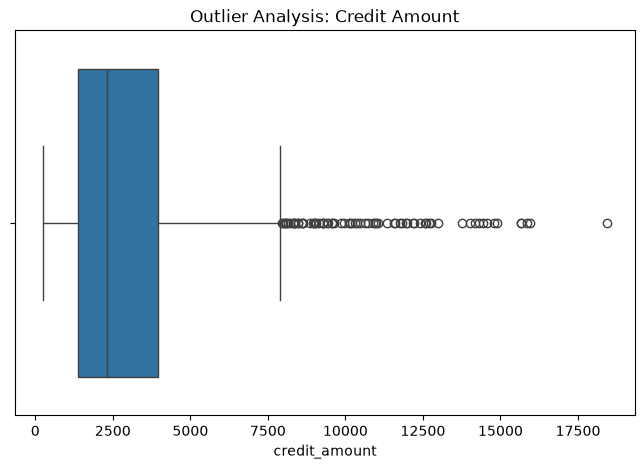

In [8]:
import seaborn as sns

# Boxplot for credit_amount
plt.figure(figsize=(8, 5))
sns.boxplot(x=df['credit_amount'])
plt.title('Outlier Analysis: Credit Amount')
plt.show()

The boxplot reveals that the **credit_amount** feature is positively skewed, with a majority of loans concentrated at lower values.

Looking for correlations between attributes.

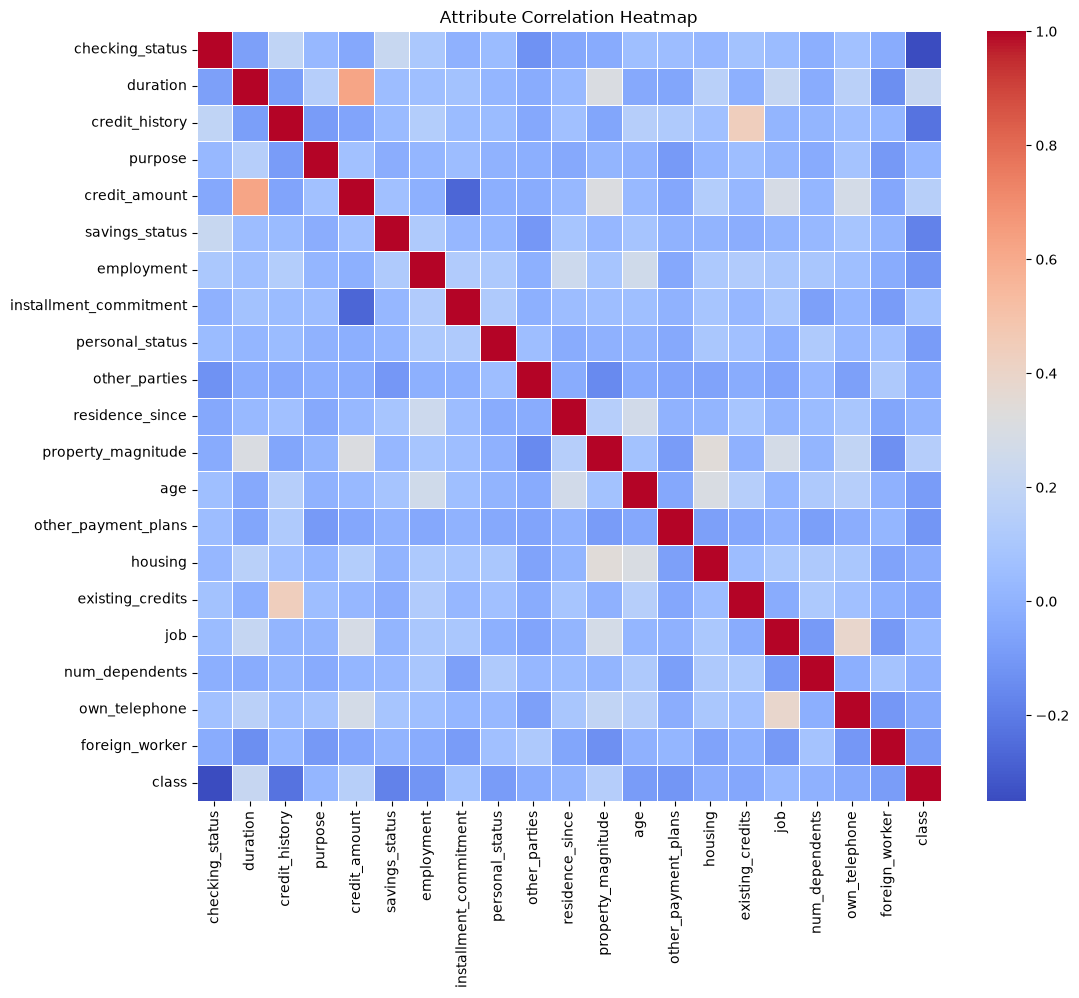

In [9]:
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Encode categorical features temporarily for correlation analysis
df_encoded = df.copy()
for col in df_encoded.select_dtypes(['category', 'object']).columns:
    df_encoded[col] = df_encoded[col].cat.codes

# 2. Calculate the correlation matrix
corr_matrix = df_encoded.corr()

# 3. Plot the heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=False, cmap='coolwarm', linewidths=0.5)
plt.title('Attribute Correlation Heatmap')
plt.show()

### Preprocessing the Data for the MLP

As in Project 2, we use a `ColumnTransformer` to standardize the numerical features and one-hot encode the categorical features. Two changes are made here compared to Project 2, since a Keras `Dense` input layer needs dense:

- `OneHotEncoder(sparse_output=False)` so the transformer outputs a dense NumPy array instead of a sparse matrix.
- The target labels (`good`/`bad`) are converted to `0`/`1` integers with a `LabelEncoder`, since Keras losses like `binary_crossentropy` expect numeric labels.

In [10]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder
import numpy as np

# 1. Identify feature types
numeric_features = ['duration', 'credit_amount', 'installment_commitment', 'residence_since', 'age', 'existing_credits', 'num_dependents']
categorical_features = ['checking_status', 'credit_history', 'purpose', 'savings_status', 'employment', 'personal_status', 'other_parties', 'property_magnitude', 'other_payment_plans', 'housing', 'job', 'own_telephone', 'foreign_worker']

# 2. Define the transformer (dense output for Keras)
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat', OneHotEncoder(sparse_output=False), categorical_features)
    ])

# 3. Fit on the training set, transform train/validation/test
X_train_processed = preprocessor.fit_transform(X_train)
X_valid_processed = preprocessor.transform(X_valid)
X_test_processed = preprocessor.transform(X_test)

# 4. Encode the target labels as 0/1 integers for Keras
label_encoder = LabelEncoder()
y_train_processed = label_encoder.fit_transform(y_train)
y_valid_processed = label_encoder.transform(y_valid)
y_test_processed = label_encoder.transform(y_test)

print(f"Processed training features shape:   {X_train_processed.shape}")
print(f"Processed validation features shape: {X_valid_processed.shape}")
print(f"Processed testing features shape:    {X_test_processed.shape}")
print(f"Classes: {list(label_encoder.classes_)} -> {list(range(len(label_encoder.classes_)))}")

Processed training features shape:   (640, 61)
Processed validation features shape: (160, 61)
Processed testing features shape:    (200, 61)
Classes: ['bad', 'good'] -> [0, 1]


The preprocessed arrays are now ready to be fed into a Keras `Sequential` MLP in the Model Building section.